In [1]:
import os 
import nltk
import pandas as pd
import numpy as np
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
os.chdir("/Users/sushovanmandal/Documents/code/learn-gen-ai/analyticsVidhya genAI/NLP using PyTorch")

In [6]:
df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1')

In [7]:
df.head()

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [8]:
# Load the SpaCy English model
# Since we are not using NER, we can disable it to speedup
nlp = spacy.load("en_core_web_sm", disable='ner')

In [9]:
def preprocess_text(texts):
    # lemmatize the tokens and store them in a list
    processed_texts = []
    for doc in nlp.pipe(texts, n_process=-1):
        lemmatized_tokens = [token.lemma_.lower() for token in doc if token.is_alpha and token.lemma_ not in nlp.Defaults.stop_words]
        
        # Join the lemmatized tokens into a string
        processed_text = " ".join(lemmatized_tokens)
        
        processed_texts.append(processed_text)
        
    return processed_texts

In [11]:
df.columns

Index(['polarity of tweet ', 'id of the tweet', 'date of the tweet', 'query',
       'user', 'text of the tweet '],
      dtype='object')

In [14]:
df['text of the tweet\xa0']

0          is upset that he can't update his Facebook by ...
1          @Kenichan I dived many times for the ball. Man...
2            my whole body feels itchy and like its on fire 
3          @nationwideclass no, it's not behaving at all....
4                              @Kwesidei not the whole crew 
                                 ...                        
1048567             My GrandMa is making Dinenr with my Mum 
1048568    Mid-morning snack time... A bowl of cheese noo...
1048569    @ShaDeLa same here  say it like from the Termi...
1048570               @DestinyHope92 im great thaanks  wbuu?
1048571                 cant wait til her date this weekend 
Name: text of the tweet , Length: 1048572, dtype: object

In [15]:
df['preprocessed_tweet'] = preprocess_text(df['text of the tweet\xa0'])

In [17]:
df['polarity of tweet\xa0'].value_counts()

polarity of tweet 
0    799996
4    248576
Name: count, dtype: int64

In [18]:
df['polarity of tweet\xa0'].nunique()

2

Only 2 classes present in polarity of tweet, so we can convert it into 0 and 1 class

In [20]:
df['sentiment'] = df['polarity of tweet\xa0'].apply(lambda x: 0 if x==0 else 1)

In [21]:
df[df['polarity of tweet\xa0']==4].head()

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet,preprocessed_tweet,sentiment
799996,4,1467822272,Mon Apr 06 22:22:45 PDT 2009,NO_QUERY,ersle,I LOVE @Health4UandPets u guys r the best!!,i love u guy r good,1
799997,4,1467822273,Mon Apr 06 22:22:45 PDT 2009,NO_QUERY,becca210,im meeting up with one of my besties tonight! ...,i m meet bestie tonight wait girl talk,1
799998,4,1467822283,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,Wingman29,"@DaRealSunisaKim Thanks for the Twitter add, S...",thank twitter add sunisa i meet hin dc area sw...,1
799999,4,1467822287,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,katarinka,Being sick can be really cheap when it hurts t...,sick cheap hurt eat real food plus friend soup,1
800000,4,1467822293,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,_EmilyYoung,@LovesBrooklyn2 he has that effect on everyone,effect,1


In [23]:
data_model = df[['preprocessed_tweet', 'sentiment']]
data_model.head()

,preprocessed_tweet,sentiment
0,upset update facebook texte cry result school ...,0
1,i dive time ball manage save rest bound,0
2,body feel itchy like fire,0
3,behave i mad i i,0
4,crew,0


# Try out Naive Bayes Classifier

In [24]:
# Naive Bayes Classifier
naive_bayes_classifier = MultinomialNB()

In [25]:
# initialize tfifd vectorizer
tfidf_vectorizer = TfidfVectorizer(min_df=0.001)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = data_model.drop('sentiment', axis=1)

In [32]:
y = data_model['sentiment']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,      # 20% for test, 80% for train
    random_state=42,    # For reproducibility
    stratify=y          # This ensures class proportions are preserved
)

In [34]:
print("Original class distribution:")
print(y.value_counts(normalize=True))

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Original class distribution:
sentiment
0    0.762939
1    0.237061
Name: proportion, dtype: float64

Train class distribution:
sentiment
0    0.762938
1    0.237062
Name: proportion, dtype: float64

Test class distribution:
sentiment
0    0.76294
1    0.23706
Name: proportion, dtype: float64


In [36]:
X_train.head()

,preprocessed_tweet
674937,n nite like i friday friday like sundays
1024986,favorite thing twitter follow ppl uk shock dri...
534412,feel good bet look great i need decorate house
596542,i upset
359595,horrible headache


In [37]:
#create the naive bayes model for the train data
tfidf_vectorizer_train = tfidf_vectorizer.fit_transform(X_train['preprocessed_tweet'])
naive_bayes_classifier.fit(tfidf_vectorizer_train, y_train)
naive_bayes_classifier.score(tfidf_vectorizer_train, y_train)

0.7933080370074995

In [38]:
#create the naive bayes model for the validation data using tfidf
tfidf_vectorizer_val = tfidf_vectorizer.transform(X_test['preprocessed_tweet'])
naive_bayes_classifier.score(tfidf_vectorizer_val, y_test)

0.7930381708509168

Model not overfitting, but the accuracy is not that high with naive bayes classifier

## tf-idf with n-grams

In [39]:
tfidf_ngram_vectorizer = TfidfVectorizer(min_df=0.001, ngram_range=(1, 3))

In [40]:
#create the naive bayes model for the train data
tfidf_ngram_vectorizer_train = tfidf_ngram_vectorizer.fit_transform(X_train['preprocessed_tweet'])
naive_bayes_classifier.fit(tfidf_ngram_vectorizer_train, y_train)
naive_bayes_classifier.score(tfidf_ngram_vectorizer_train, y_train)

0.7951009528441677

Not much change in train accuracy with n-grams

# ANN model trial

In [41]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [42]:
tfidf_ann_vectorizer = TfidfVectorizer(min_df=0.001)

In [43]:
# fitting the ann_vectorizer to the train and validation data
features_train = tfidf_ann_vectorizer.fit_transform(X_train['preprocessed_tweet'])
features_validation = tfidf_ann_vectorizer.transform(X_test['preprocessed_tweet'])

In [49]:
# converting the features_train and features_validation 
features_train = torch.tensor(features_train.toarray(), dtype=torch.float32)
features_validation = torch.tensor(features_validation.toarray(), dtype=torch.float32)

In [64]:
y_train.values

array([0, 1, 0, ..., 0, 0, 0], shape=(838857,))

In [65]:
# convert target variables into pytorch tensors
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_validation = torch.tensor(y_test.values, dtype=torch.float32)

In [66]:
# initialise TensorDataset  object
train_dataset = TensorDataset(features_train, y_train)
val_dataset = TensorDataset(features_validation, y_validation)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

In [56]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.fc3 = nn.Sigmoid()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

In [68]:
model = ANNModel(input_size=features_train.shape[1], hidden_size=64, output_size=1, dropout_rate=0.5)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

Training started...

Epoch 1/30, Loss: 0.4370, Val Loss: 0.4210
  → Validation loss improved
Epoch 2/30, Loss: 0.4243, Val Loss: 0.4199
  → Validation loss improved
Epoch 3/30, Loss: 0.4228, Val Loss: 0.4191
  → Validation loss improved
Epoch 4/30, Loss: 0.4220, Val Loss: 0.4184
  → Validation loss improved
Epoch 5/30, Loss: 0.4212, Val Loss: 0.4177
  → Validation loss improved
Epoch 6/30, Loss: 0.4205, Val Loss: 0.4175
  → Validation loss improved
Epoch 7/30, Loss: 0.4196, Val Loss: 0.4174
  → Validation loss improved
Epoch 8/30, Loss: 0.4191, Val Loss: 0.4169
  → Validation loss improved
Epoch 9/30, Loss: 0.4186, Val Loss: 0.4168
  → Validation loss improved
Epoch 10/30, Loss: 0.4182, Val Loss: 0.4165
  → Validation loss improved
Epoch 11/30, Loss: 0.4175, Val Loss: 0.4160
  → Validation loss improved
Epoch 12/30, Loss: 0.4172, Val Loss: 0.4158
  → Validation loss improved
Epoch 13/30, Loss: 0.4166, Val Loss: 0.4154
  → Validation loss improved
Epoch 14/30, Loss: 0.4166, Val Loss: 0.

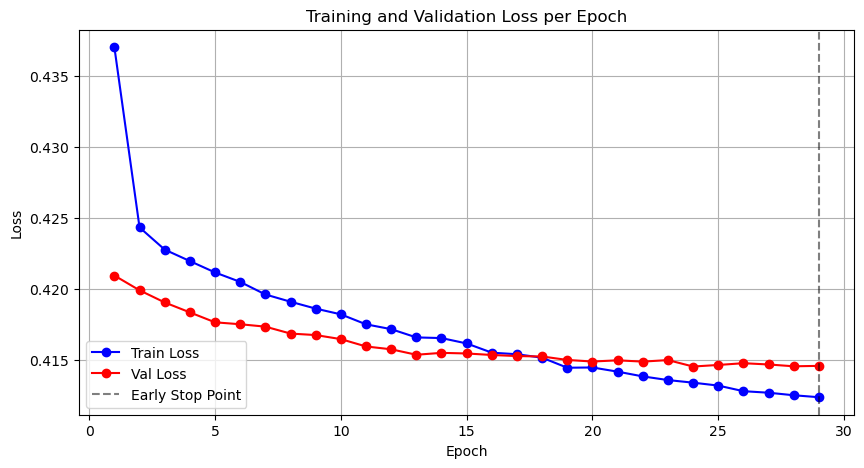


Training completed after 29 epochs.


In [69]:
import matplotlib.pyplot as plt

num_epochs = 30
losses = []
val_losses = []

# Early Stopping Parameters
patience = 5          # How many epochs to wait after val loss stops improving
best_val_loss = float('inf')  # Initialize best validation loss
epochs_no_improve = 0         # Counter for epochs without improvement
early_stop = False            # Flag to stop training

print("Training started...\n")

for epoch in range(num_epochs):
    if early_stop:
        print("Early stopping triggered!")
        break
    
    model.train()
    total_loss = 0
    count = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    
    average_loss = total_loss / count
    losses.append(average_loss)
    
    # Validation phase
    model.eval()  # Set model to evaluation mode (important for dropout, batchnorm, etc.)
    total_val_loss = 0
    val_count = 0
    
    with torch.no_grad():  # Disable gradient computation for validation
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.float())
            total_val_loss += val_loss.item()
            val_count += 1
    
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Early Stopping Logic
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        epochs_no_improve = 0
        # Optional: Save the best model
        # torch.save(model.state_dict(), 'best_model.pth')
        print("  → Validation loss improved")
    else:
        epochs_no_improve += 1
        print(f"  → No improvement in val loss for {epochs_no_improve} epoch(s)")
        
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            early_stop = True

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='b', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', linestyle='-', color='r', label='Val Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.axvline(x=len(losses), color='k', linestyle='--', alpha=0.5, label='Early Stop Point')
plt.legend()
plt.show()

print(f"\nTraining completed after {len(losses)} epochs.")

In [70]:
def calculate_accuracy(loader):
    model.eval()  # Set the model to evaluation mode
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            predicted = outputs.squeeze() > 0.5  # Apply threshold to convert probabilities to binary predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy}%')
print(f'Validation Accuracy: {val_accuracy}%')


Training Accuracy: 81.8407666622559%
Validation Accuracy: 81.15919223708366%


Model with stable performance, with no overfitting

# Trying out a more complex ANN model

In [71]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, dropout_rate=0.5):
        super(ANNModel, self).__init__()
        
        # Ensure hidden_size is integer and even if needed
        hidden_size = int(hidden_size)
        hidden_size2 = hidden_size // 2
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_size, hidden_size2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_size2, output_size)
        )
        
        # Binary classification or regression
        self.output_activation = nn.Sigmoid()  # Only if using BCELoss

    def forward(self, x):
        out = self.network(x)
        out = self.output_activation(out)
        return out

In [72]:
model = ANNModel(input_size=features_train.shape[1], hidden_size=128, output_size=1, dropout_rate=0.5)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

Training started...

Epoch 1/30, Loss: 0.4354, Val Loss: 0.4211
  → Validation loss improved
Epoch 2/30, Loss: 0.4253, Val Loss: 0.4198
  → Validation loss improved
Epoch 3/30, Loss: 0.4228, Val Loss: 0.4183
  → Validation loss improved
Epoch 4/30, Loss: 0.4204, Val Loss: 0.4170
  → Validation loss improved
Epoch 5/30, Loss: 0.4185, Val Loss: 0.4164
  → Validation loss improved
Epoch 6/30, Loss: 0.4173, Val Loss: 0.4161
  → Validation loss improved
Epoch 7/30, Loss: 0.4159, Val Loss: 0.4153
  → Validation loss improved
Epoch 8/30, Loss: 0.4145, Val Loss: 0.4163
  → No improvement in val loss for 1 epoch(s)
Epoch 9/30, Loss: 0.4133, Val Loss: 0.4154
  → No improvement in val loss for 2 epoch(s)
Epoch 10/30, Loss: 0.4121, Val Loss: 0.4154
  → No improvement in val loss for 3 epoch(s)
Epoch 11/30, Loss: 0.4112, Val Loss: 0.4153
  → Validation loss improved
Epoch 12/30, Loss: 0.4103, Val Loss: 0.4157
  → No improvement in val loss for 1 epoch(s)
Epoch 13/30, Loss: 0.4096, Val Loss: 0.4154


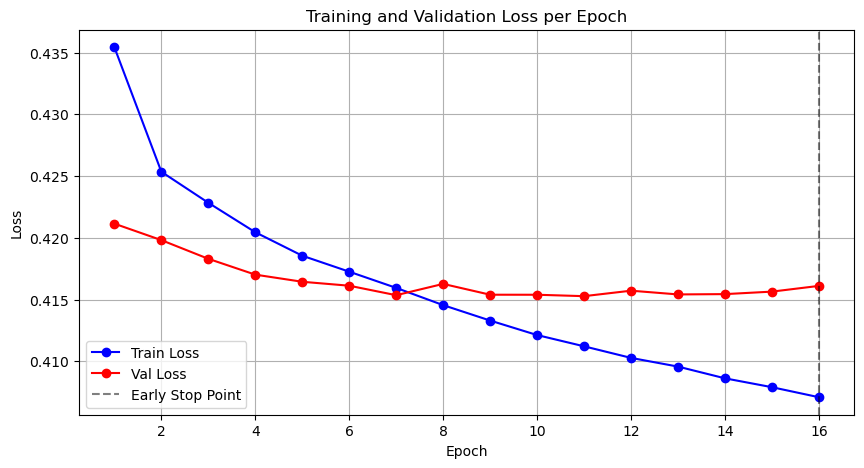


Training completed after 16 epochs.


In [73]:
num_epochs = 30
losses = []
val_losses = []

# Early Stopping Parameters
patience = 5          # How many epochs to wait after val loss stops improving
best_val_loss = float('inf')  # Initialize best validation loss
epochs_no_improve = 0         # Counter for epochs without improvement
early_stop = False            # Flag to stop training

print("Training started...\n")

for epoch in range(num_epochs):
    if early_stop:
        print("Early stopping triggered!")
        break
    
    model.train()
    total_loss = 0
    count = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    
    average_loss = total_loss / count
    losses.append(average_loss)
    
    # Validation phase
    model.eval()  # Set model to evaluation mode (important for dropout, batchnorm, etc.)
    total_val_loss = 0
    val_count = 0
    
    with torch.no_grad():  # Disable gradient computation for validation
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.float())
            total_val_loss += val_loss.item()
            val_count += 1
    
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Early Stopping Logic
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        epochs_no_improve = 0
        # Optional: Save the best model
        # torch.save(model.state_dict(), 'best_model.pth')
        print("  → Validation loss improved")
    else:
        epochs_no_improve += 1
        print(f"  → No improvement in val loss for {epochs_no_improve} epoch(s)")
        
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            early_stop = True

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='b', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', linestyle='-', color='r', label='Val Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.axvline(x=len(losses), color='k', linestyle='--', alpha=0.5, label='Early Stop Point')
plt.legend()
plt.show()

print(f"\nTraining completed after {len(losses)} epochs.")

In [74]:
def calculate_accuracy(loader):
    model.eval()  # Set the model to evaluation mode
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            predicted = outputs.squeeze() > 0.5  # Apply threshold to convert probabilities to binary predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy}%')
print(f'Validation Accuracy: {val_accuracy}%')


Training Accuracy: 82.56997318970933%
Validation Accuracy: 81.16205326276136%


No such improvement in validation accuracy